In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import polars as pl
from pathlib import Path
import matplotlib.pyplot as plt
import librosa
import IPython.display as ipd
import numpy as np


sys.path.append(os.path.abspath("../.."))

# import src.utils.eda as eda

In [ ]:
# パスの設定（環境に合わせて微調整してください）
BASE_DIR = Path("../../input/birdclef-2026")
TRAIN_AUDIO_DIR = BASE_DIR / "train_audio"
TRAIN_CSV = BASE_DIR / "train.csv"

# PolarsでCSV読み込み
df_train = pl.read_csv(TRAIN_CSV, infer_schema_length=None)

# ファイルパス列を新しく作成（例: input/birdclef-2026/train_audio/22930/xxxx.ogg）
df_train = df_train.with_columns(
    (str(TRAIN_AUDIO_DIR) + "/" + pl.col("filename")).alias("filepath")
)

print("データ数:", df_train.height)
df_train.head()

データ数: 35549


primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection,filepath
str,str,str,f64,f64,str,str,str,i64,str,str,f64,str,str,str,str
"""1161364""","""[]""","""[]""",-22.7562,-46.8666,"""Guyalna cuta""","""Guyalna cuta""","""Insecta""",1161364,"""Lucas Barbosa""","""cc-by-nc""",0.0,"""https://static.inaturalist.org…","""1161364/iNat1216197.ogg""","""iNat""","""../../input/birdclef-2026/trai…"
"""1161364""","""[]""","""[]""",-22.7558,-46.87,"""Guyalna cuta""","""Guyalna cuta""","""Insecta""",1161364,"""Lucas Barbosa""","""cc-by-nc""",0.0,"""https://static.inaturalist.org…","""1161364/iNat1114648.ogg""","""iNat""","""../../input/birdclef-2026/trai…"
"""1161364""","""[]""","""[]""",-22.7547,-46.8728,"""Guyalna cuta""","""Guyalna cuta""","""Insecta""",1161364,"""Lucas Barbosa""","""cc-by-nc""",0.0,"""https://static.inaturalist.org…","""1161364/iNat810195.ogg""","""iNat""","""../../input/birdclef-2026/trai…"
"""1161364""","""[]""","""[]""",-22.7547,-46.8728,"""Guyalna cuta""","""Guyalna cuta""","""Insecta""",1161364,"""Lucas Barbosa""","""cc-by-nc""",0.0,"""https://static.inaturalist.org…","""1161364/iNat818781.ogg""","""iNat""","""../../input/birdclef-2026/trai…"
"""1161364""","""[]""","""[]""",-22.7426,-46.8985,"""Guyalna cuta""","""Guyalna cuta""","""Insecta""",1161364,"""Lucas Barbosa""","""cc-by-nc""",0.0,"""https://static.inaturalist.org…","""1161364/iNat556514.ogg""","""iNat""","""../../input/birdclef-2026/trai…"


/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


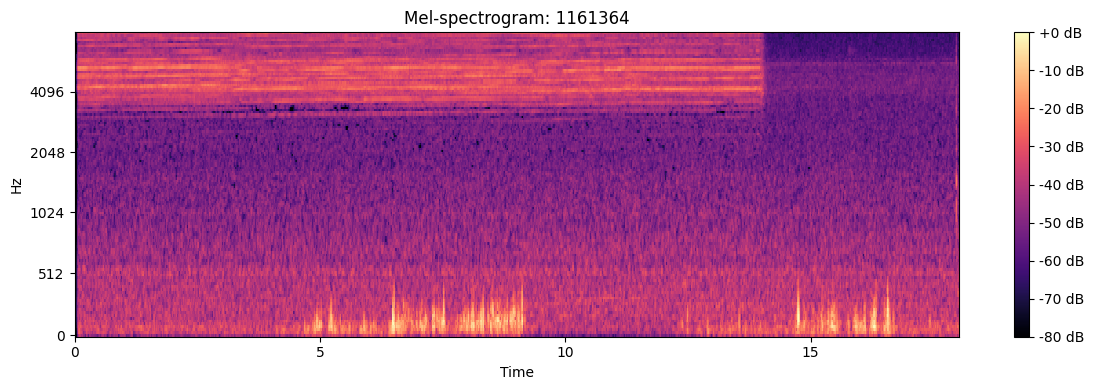

File: iNat1216197.ogg | Label: 1161364


In [19]:
# 試しに1つ目の音声ファイルをピックアップ
sample_path = df_train["filepath"][0]
sample_label = df_train["primary_label"][0] # 鳥の種類（正解ラベル）

# 1. 音声のロード (sr=Noneで元のサンプリングレートを維持)
# 警告が出ることがありますが無視して構いません
y, sr = librosa.load(sample_path, sr=None)

# 2. メルスペクトログラム（人間の聴覚特性に合わせた周波数の可視化）の作成
# これが実際にCNN/ViTに入力される「画像」の元になります
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
S_dB = librosa.power_to_db(S, ref=np.max)

# 3. 描画
plt.figure(figsize=(12, 4))
librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel', fmax=8000, cmap='magma')
plt.colorbar(format='%+2.0f dB')
plt.title(f'Mel-spectrogram: {sample_label}')
plt.tight_layout()
plt.show()

# 4. Notebook上で音声を再生するウィジェットを表示
print(f"File: {sample_path.split('/')[-1]} | Label: {sample_label}")
ipd.Audio(sample_path)

In [20]:
import soundfile as sf
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm

# 関数: 1ファイル分のメタデータを取得
def get_audio_meta(filepath):
    try:
        info = sf.info(filepath)
        return {
            "filepath": filepath,
            "duration": info.duration,       # 秒数
            "samplerate": info.samplerate,   # サンプリングレート
        }
    except Exception:
        return {"filepath": filepath, "duration": None, "samplerate": None}

# 並列処理で全ファイルを走査
filepaths = df_train["filepath"].to_list()
results = []

with ProcessPoolExecutor() as executor:
    # 進行状況バーを表示しながら並列処理
    for res in tqdm(executor.map(get_audio_meta, filepaths), total=len(filepaths)):
        results.append(res)

# Polarsデータフレーム化して元のCSVと結合
df_meta = pl.DataFrame(results)
df_train = df_train.join(df_meta, on="filepath", how="left")

# 再生時間（duration）の分布を確認
print(df_train["duration"].describe())

100%|██████████| 35549/35549 [00:09<00:00, 3781.06it/s]

shape: (9, 2)
┌────────────┬───────────┐
│ statistic  ┆ value     │
│ ---        ┆ ---       │
│ str        ┆ f64       │
╞════════════╪═══════════╡
│ count      ┆ 35549.0   │
│ null_count ┆ 0.0       │
│ mean       ┆ 34.882595 │
│ std        ┆ 74.861287 │
│ min        ┆ 0.008     │
│ 25%        ┆ 10.788562 │
│ 50%        ┆ 21.0      │
│ 75%        ┆ 39.837313 │
│ max        ┆ 6881.097  │
└────────────┴───────────┘


In [22]:
# 鳥の種類（ラベル）ごとのデータ数を確認
label_counts = df_train["primary_label"].value_counts().sort("count", descending=True)
print(label_counts.head(10))  # データが多い鳥トップ10
print(label_counts.tail(10))  # データが少ない鳥ワースト10

shape: (10, 2)
┌───────────────┬───────┐
│ primary_label ┆ count │
│ ---           ┆ ---   │
│ str           ┆ u32   │
╞═══════════════╪═══════╡
│ rubthr1       ┆ 499   │
│ banana        ┆ 498   │
│ fepowl        ┆ 497   │
│ soulap1       ┆ 497   │
│ houspa        ┆ 496   │
│ coffal1       ┆ 495   │
│ osprey        ┆ 495   │
│ socfly1       ┆ 494   │
│ yeofly1       ┆ 493   │
│ compau        ┆ 493   │
└───────────────┴───────┘
shape: (10, 2)
┌───────────────┬───────┐
│ primary_label ┆ count │
│ ---           ┆ ---   │
│ str           ┆ u32   │
╞═══════════════╪═══════╡
│ 555123        ┆ 3     │
│ 25214         ┆ 3     │
│ 476521        ┆ 3     │
│ 70711         ┆ 2     │
│ 24321         ┆ 2     │
│ 209233        ┆ 2     │
│ 116570        ┆ 1     │
│ 23724         ┆ 1     │
│ 23150         ┆ 1     │
│ 516975        ┆ 1     │
└───────────────┴───────┘


In [9]:
# 生データの読み込み
train_data = pd.read_csv("../../input/birdclef-2026/train.csv")
train_soundscapes = pd.read_csv("../../input/birdclef-2026/train_soundscapes_labels.csv")
taxonomy = pd.read_csv("../../input/birdclef-2026/taxonomy.csv")
sample_submission = pd.read_csv("../../input/birdclef-2026/sample_submission.csv")

In [12]:
train_data.head()

,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat
3,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/818781.m...,1161364/iNat818781.ogg,iNat
4,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/556514.m...,1161364/iNat556514.ogg,iNat


In [5]:
train_soundscapes.head()

,filename,start,end,primary_label
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:00,00:00:05,22961;23158;24321;517063;65380
1,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:05,00:00:10,22961;23158;24321;517063;65380
2,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:10,00:00:15,22961;23158;24321;517063;65380
3,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:15,00:00:20,22961;23158;24321;517063;65380
4,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:20,00:00:25,22961;23158;24321;517063;65380
